### Import Packages

In [154]:
!pip install catboost xgboost

  Using cached catboost-1.2.10-cp313-cp313-manylinux2014_x86_64.whl.metadata (1.4 kB)
  Using cached xgboost-3.3.0-py3-none-manylinux_2_28_x86_64.whl.metadata (2.0 kB)
  Using cached graphviz-0.21-py3-none-any.whl.metadata (12 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 837.6 kB/s eta 0:00:00m eta 0:00:010:00:03
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 212.8 kB/s eta 0:00:00m eta 0:00:010:00:17
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [catboost]━━━━━━━━━ 2/3 [catboost]


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
import torch
import joblib

In [2]:
BASE_DIR = os.path.abspath("../")
DATA_PATH = os.path.join(BASE_DIR, "data")
RAW_DATA = os.path.join(DATA_PATH, "raw")
PROCESSED_DATA = os.path.join(DATA_PATH, "processed")

### Load Dataset

In [3]:
os.listdir(RAW_DATA)

['Telco-Customer-Churn.csv']

In [4]:
df = pd.read_csv(os.path.join(RAW_DATA, "Telco-Customer-Churn.csv"))
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Preprocessing

In [5]:
df.shape

(7043, 21)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df = df[df["TotalCharges"] != " "]

In [8]:
df["TotalCharges"] = df["TotalCharges"].astype(float)

In [9]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [10]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

### EDA

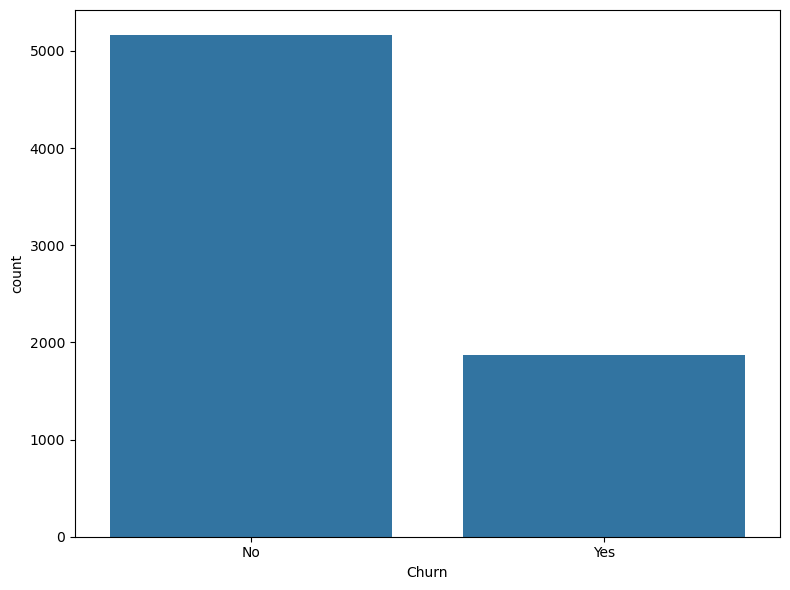

In [12]:
plt.figure(figsize=(8, 6))

sns.countplot(data=df, x="Churn")

plt.tight_layout()
plt.show()

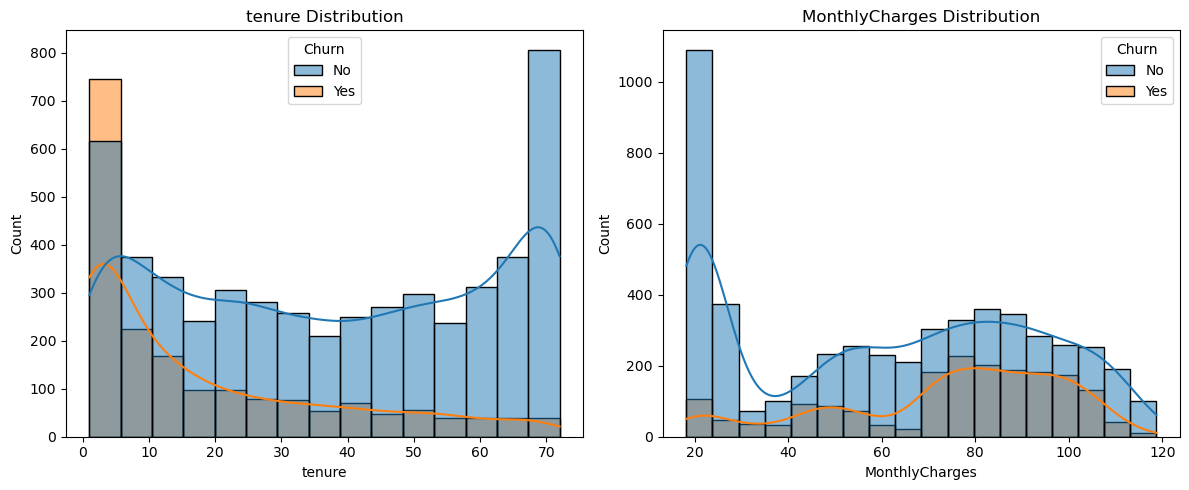

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

for idx, col in enumerate(["tenure", "MonthlyCharges"]):
    sns.histplot(data=df, x=col, hue="Churn", kde=True, ax=ax[idx])
    ax[idx].set_title(f"{col} Distribution")

plt.tight_layout()
plt.show()

<Axes: >

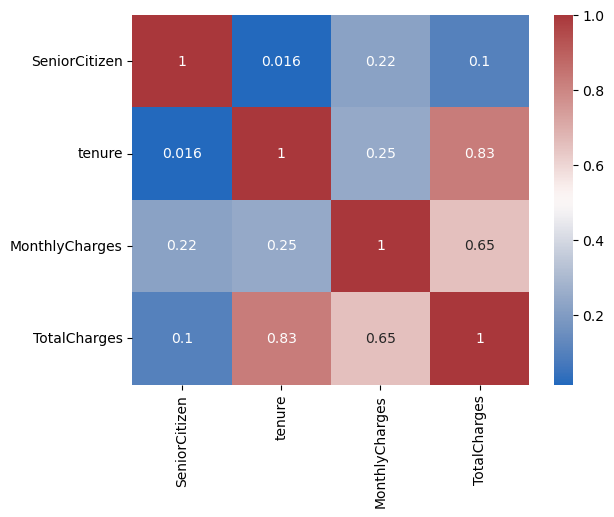

In [14]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="vlag")

### Features Engineering

In [15]:
df = df.drop(columns=["customerID"])

In [16]:
encoder = LabelEncoder()
df["Churn"] = encoder.fit_transform(df["Churn"])

In [17]:
cols = [col for col in df.select_dtypes("object")]

In [18]:
df = pd.get_dummies(data=df, columns=cols, drop_first=True)
df

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,1990.50,0,True,True,True,True,False,...,False,True,False,True,True,False,True,False,False,True
7039,0,72,103.20,7362.90,0,False,True,True,True,False,...,False,True,False,True,True,False,True,True,False,False
7040,0,11,29.60,346.45,0,False,True,True,False,True,...,False,False,False,False,False,False,True,False,True,False
7041,1,4,74.40,306.60,1,True,True,False,True,False,...,False,False,False,False,False,False,True,False,False,True


In [19]:
bool_cols = [col for col in df.select_dtypes("bool")]
df[bool_cols] = df[bool_cols].astype(int)

### ML Models

In [20]:
x = df.drop(columns=["Churn"])
y = df["Churn"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=41)
x_val, x_test, y_val, y_test = train_test_split(x_test, y_test, test_size=0.5, random_state=41, stratify=y_test)

In [21]:
rf = RandomForestClassifier(
    n_estimators=700,
    criterion="gini",
    random_state=41,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features="sqrt",
    bootstrap=True,
    class_weight="balanced"
)

svm = SVC(
    kernel="rbf",
    C=3,
    gamma="scale",
    class_weight="balanced",
    probability=True,
    random_state=41,
    cache_size=2000
)

lr = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="liblinear",
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

xgb = XGBClassifier(
    n_estimators=700,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.5,
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=2.76,
    random_state=42,
    n_jobs=-1
)

cat = CatBoostClassifier(
    iterations=3700,
    learning_rate=0.025,
    depth=6,
    l2_leaf_reg=8,
    loss_function="Logloss",
    eval_metric="AUC",
    auto_class_weights="Balanced",
    random_seed=42,
    verbose=200,
    early_stopping_rounds=200,
    bootstrap_type="Bayesian",
    bagging_temperature=1.0,
    random_strength=1.5,
    border_count=254
)

In [22]:
for model in [rf, svm, lr, xgb, cat]:
    model.fit(x_train, y_train)

0:	total: 50.2ms	remaining: 3m 5s
200:	total: 597ms	remaining: 10.4s
400:	total: 1.14s	remaining: 9.41s
600:	total: 1.7s	remaining: 8.75s
800:	total: 2.24s	remaining: 8.12s
1000:	total: 2.8s	remaining: 7.54s
1200:	total: 3.32s	remaining: 6.9s
1400:	total: 3.86s	remaining: 6.34s
1600:	total: 4.4s	remaining: 5.76s
1800:	total: 4.93s	remaining: 5.2s
2000:	total: 5.49s	remaining: 4.66s
2200:	total: 6.05s	remaining: 4.12s
2400:	total: 6.6s	remaining: 3.57s
2600:	total: 7.15s	remaining: 3.02s
2800:	total: 7.71s	remaining: 2.47s
3000:	total: 8.25s	remaining: 1.92s
3200:	total: 8.79s	remaining: 1.37s
3400:	total: 9.33s	remaining: 820ms
3600:	total: 9.89s	remaining: 272ms
3699:	total: 10.2s	remaining: 0us


In [23]:
rf_predicted = rf.predict(x_test)
svm_predicted = svm.predict(x_test)
lr_predicted = lr.predict(x_test)
xgb_predicted = xgb.predict(x_test)
cat_predicted = cat.predict(x_test)

In [24]:
print("=========== Random Forest ===========\n")
print(classification_report(y_test, rf_predicted))
print("=========== Support Vector Machine ===========\n")
print(classification_report(y_test, svm_predicted))
print("=========== Logistic Regression ===========\n")
print(classification_report(y_test, lr_predicted))
print("=========== XGBoost Classifier ===========\n")
print(classification_report(y_test, xgb_predicted))
print("=========== CatBoost Classifier ===========\n")
print(classification_report(y_test, cat_predicted))

=========== Random Forest ===========

              precision    recall  f1-score   support

           0       0.89      0.78      0.83       512
           1       0.56      0.73      0.64       192

    accuracy                           0.77       704
   macro avg       0.72      0.76      0.73       704
weighted avg       0.80      0.77      0.78       704

=========== Support Vector Machine ===========

              precision    recall  f1-score   support

           0       0.85      0.69      0.76       512
           1       0.45      0.67      0.54       192

    accuracy                           0.69       704
   macro avg       0.65      0.68      0.65       704
weighted avg       0.74      0.69      0.70       704

=========== Logistic Regression ===========

              precision    recall  f1-score   support

           0       0.92      0.71      0.80       512
           1       0.51      0.83      0.63       192

    accuracy                           0.74       

### ANN Model

In [25]:
class MyDataset(Dataset):
    def __init__(self, features, targets):
        self.features = features.to_numpy(dtype=np.float32)
        self.targets = targets.to_numpy(dtype=np.float32)

        self.features = torch.tensor(self.features, dtype=torch.float32)
        self.targets = torch.tensor(self.targets, dtype=torch.float32)

    def __len__(self): return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.targets[idx]

train_set = MyDataset(x_train, y_train)
val_set = MyDataset(x_val, y_val)
test_set = MyDataset(x_test, y_test)

train_loader = DataLoader(train_set, batch_size=8, shuffle=True)
val_loader = DataLoader(val_set, batch_size=8, shuffle=False)
test_loader = DataLoader(test_set, batch_size=8, shuffle=False)

In [26]:
class ANNModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.l1 = torch.nn.Linear(30, 32)
        self.a1 = torch.nn.ReLU()
        self.d1 = torch.nn.Dropout(0.1)

        
        self.l2 = torch.nn.Linear(32, 64)
        self.a2 = torch.nn.ReLU()
        self.d2 = torch.nn.Dropout(0.1)

        
        self.l3 = torch.nn.Linear(64, 128)
        self.a3 = torch.nn.ReLU()
        self.d3 = torch.nn.Dropout(0.1)

        
        self.l4 = torch.nn.Linear(128, 64)
        self.a4 = torch.nn.ReLU()
        self.d4 = torch.nn.Dropout(0.2)

        
        self.l5 = torch.nn.Linear(64, 32)
        self.a5 = torch.nn.ReLU()
        self.d5 = torch.nn.Dropout(0.1)

        
        self.l6 = torch.nn.Linear(32, 1)

    def forward(self, x):
        x = self.l1(x)
        x = self.a1(x)
        x = self.d1(x)

        
        x = self.l2(x)
        x = self.a2(x)
        x = self.d2(x)

        
        x = self.l3(x)
        x = self.a3(x)
        x = self.d3(x)

        
        x = self.l4(x)
        x = self.a4(x)
        x = self.d4(x)

        
        x = self.l5(x)
        x = self.a5(x)
        x = self.d5(x)

        
        x = self.l6(x)

        return x

In [27]:
ann = ANNModel()

In [28]:
loss_fn = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(ann.parameters(), lr=1e-4)

In [29]:
num_epochs = 80

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

for epoch in range(num_epochs):
    ann.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=True)

    for features, targets in pbar:
        optimizer.zero_grad()

        outputs = ann(features)

        targets = targets.float().view(-1, 1)

        loss = loss_fn(outputs, targets)

        loss.backward()
        optimizer.step()

        probs = torch.sigmoid(outputs)
        preds = (probs >= 0.5).float()

        train_loss += loss.item() * features.size(0)
        train_correct += (preds == targets).sum().item()
        train_total += targets.size(0)

        batch_acc = (preds == targets).float().mean().item()

        pbar.set_postfix(
            batch_loss=f"{loss.item():.4f}",
            batch_acc=f"{batch_acc:.2f}"
        )

    avg_train_loss = train_loss / train_total
    avg_train_acc = train_correct / train_total

    ann.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for features, targets in val_loader:
            outputs = ann(features)

            targets = targets.float().view(-1, 1)

            loss = loss_fn(outputs, targets)

            probs = torch.sigmoid(outputs)
            preds = (probs >= 0.5).float()

            val_loss += loss.item() * features.size(0)
            val_correct += (preds == targets).sum().item()
            val_total += targets.size(0)

    avg_val_loss = val_loss / val_total
    avg_val_acc = val_correct / val_total

    history["train_loss"].append(avg_train_loss)
    history["train_acc"].append(avg_train_acc)
    history["val_loss"].append(avg_val_loss)
    history["val_acc"].append(avg_val_acc)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"| Train Loss: {avg_train_loss:.4f} "
        f"| Train Acc: {avg_train_acc:.4f} "
        f"| Val Loss: {avg_val_loss:.4f} "
        f"| Val Acc: {avg_val_acc:.4f}"
    )

Epoch 1/80: 100%|█| 704/704 [00:03<00:00, 222.05it/s, batch_acc=1.00, batch_loss


Epoch [1/80] | Train Loss: 0.9030 | Train Acc: 0.6542 | Val Loss: 0.6190 | Val Acc: 0.6913


Epoch 2/80: 100%|█| 704/704 [00:03<00:00, 233.24it/s, batch_acc=1.00, batch_loss


Epoch [2/80] | Train Loss: 0.6358 | Train Acc: 0.6900 | Val Loss: 0.6061 | Val Acc: 0.6885


Epoch 3/80: 100%|█| 704/704 [00:03<00:00, 231.80it/s, batch_acc=1.00, batch_loss


...

Epoch [78/80] | Train Loss: 0.4271 | Train Acc: 0.7972 | Val Loss: 0.4761 | Val Acc: 0.7809


Epoch 79/80: 100%|█| 704/704 [00:03<00:00, 200.93it/s, batch_acc=0.00, batch_los


Epoch [79/80] | Train Loss: 0.4290 | Train Acc: 0.7972 | Val Loss: 0.4758 | Val Acc: 0.7809


Epoch 80/80: 100%|█| 704/704 [00:04<00:00, 173.77it/s, batch_acc=1.00, batch_los


Epoch [80/80] | Train Loss: 0.4258 | Train Acc: 0.8000 | Val Loss: 0.4805 | Val Acc: 0.7824


In [30]:
ann.eval()

test_loss = 0.0
test_correct = 0
test_total = 0

all_targets = []
all_preds = []
all_probs = []

with torch.no_grad():
    for features, targets in test_loader:
        outputs = ann(features)

        targets_loss = targets.float().view(-1, 1)

        loss = loss_fn(outputs, targets_loss)

        probs = torch.sigmoid(outputs)
        preds = (probs >= 0.5).float()

        test_loss += loss.item() * features.size(0)
        test_correct += (preds == targets_loss).sum().item()
        test_total += targets.size(0)

        all_targets.extend(targets.cpu().numpy())
        all_preds.extend(preds.cpu().numpy().flatten())
        all_probs.extend(probs.cpu().numpy().flatten())

avg_test_loss = test_loss / test_total
test_acc = test_correct / test_total

print(f"Test Loss: {avg_test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Test Loss: 0.4420
Test Accuracy: 0.7983


In [31]:
print(classification_report(
    all_targets,
    all_preds,
    target_names=["Class 0", "Class 1"]
))

              precision    recall  f1-score   support

     Class 0       0.85      0.88      0.86       512
     Class 1       0.65      0.57      0.61       192

    accuracy                           0.80       704
   macro avg       0.75      0.73      0.74       704
weighted avg       0.79      0.80      0.79       704



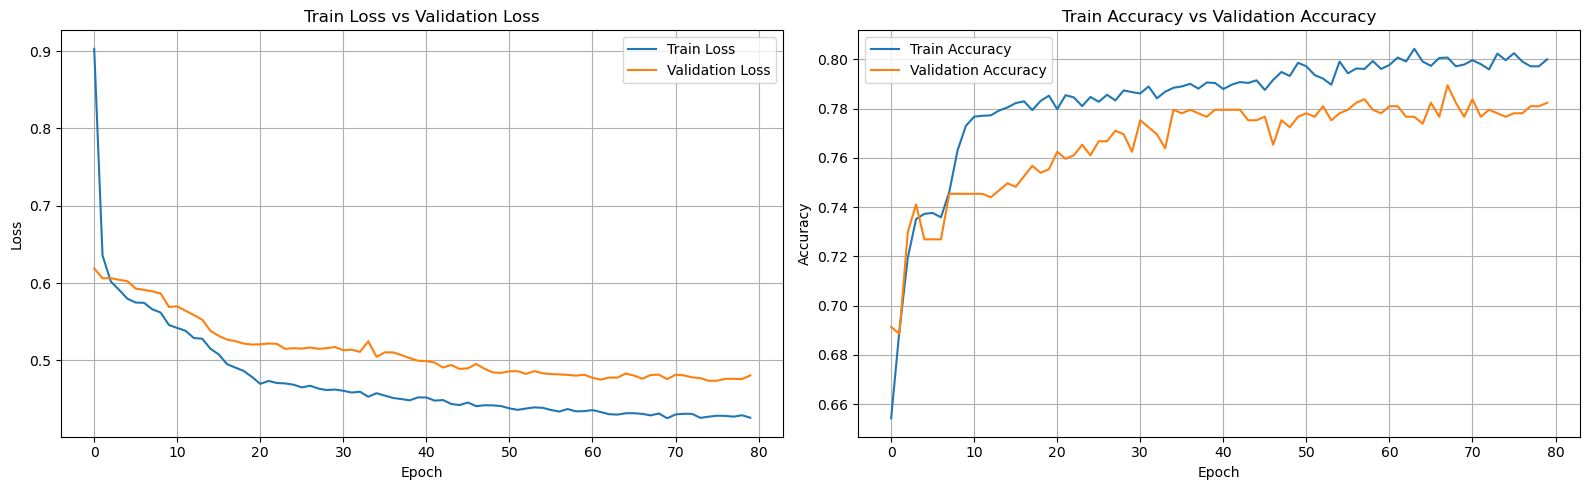

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(history["train_loss"], label="Train Loss")
axes[0].plot(history["val_loss"], label="Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Train Loss vs Validation Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history["train_acc"], label="Train Accuracy")
axes[1].plot(history["val_acc"], label="Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Train Accuracy vs Validation Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()